In [1]:
import ReadPinocchio5 as rp
import numpy as np
import matplotlib.pyplot as plt

from scipy.interpolate import interp1d

from astropy.cosmology import Planck18 as cosmo
from astropy import units as u
from astropy.io import fits

import pandas as pd

In [2]:
input_fname = '/mnt/data_cat3/moriwaki/Pinocchio/my_lightcone/output_large/pinocchio.r00001.plc.out'
myplc = rp.plc(input_fname)
           
logm = np.log10( myplc.data["Mass"] ) # [Msun/h]
theta = myplc.data["theta"] 
phi = myplc.data["phi"]

redshift_obs = myplc.data["obsz"]
redshift_real = myplc.data["truez"]

theta = ( 90. - theta )  # [deg]
pos_x = theta * np.cos( phi * np.pi / 180. ) # [deg]
pos_y = theta * np.sin( phi * np.pi / 180. ) # [deg]

The catalog is written in 1 file
reading header of file /mnt/data_cat3/moriwaki/Pinocchio/my_lightcone/output_large/pinocchio.r00001.plc.out
This is new light output format, record length: 32
done with file /mnt/data_cat3/moriwaki/Pinocchio/my_lightcone/output_large/pinocchio.r00001.plc.out
Reading plc done, 6515727 groups found


In [115]:
def Ha_LF(z, lumi):
    alpha = -1.6
    L = 0.45*z + 41.87
    Lstar = 10**L
    f = interp1d([0, 0.4, 0.84, 1.47, 2.23], [-3.15, -2.9, -2.47, -2.61, -2.78], bounds_error=False, fill_value = 'extrapolate')
    psi = f(z)
    Psi = np.log(10)*10**psi*(lumi/Lstar)**alpha * np.exp(-lumi/Lstar)*(lumi/Lstar)
    return Psi

def OIII_LF(z, lumi):
    alpha = -1.6
    f = interp1d([0.84, 1.42, 2.23, 3.24], [41.79, 42.06, 42.66, 42.83], bounds_error=False, fill_value = 'extrapolate')
    L = f(z)
    Lstar = 10**L
    f = interp1d([0.84, 1.42, 2.23, 3.24], [-2.55, -2.61, -3.03, -3.31], bounds_error=False, fill_value = 'extrapolate')
    psi = f(z)
    Psi = np.log(10)*10**psi*(lumi/Lstar)**alpha * np.exp(-lumi/Lstar)*(lumi/Lstar)
    return Psi

In [118]:
def Volume(zmin, zmax):
    theta = 7.5 * u.deg
    solid_angle = 2 * np.pi * (1 - np.cos(theta.to(u.rad))) * u.sr

    # 赤方偏移範囲
    z1 = zmin
    z2 = zmax

    # comoving volumeの差（立体角で割ってない、全立体角の体積）
    vol1 = cosmo.comoving_volume(z1)
    vol2 = cosmo.comoving_volume(z2)

    # 差分を計算（全空間での体積の差）
    volume_total = (vol2 - vol1)

    # 求めたい体積 = 全体積 × (対象領域の立体角 / 4π)
    fraction = (solid_angle / (4 * np.pi * u.sr))
    volume_partial = volume_total * fraction
    return volume_partial.value

def MassFunc(logM, redshift, zmin, zmax):
    volume = Volume(zmin, zmax)
    massbin = np.linspace(12, 15, 40)
    hist, bin = np.histogram(logM[(redshift>zmin) & (redshift<zmax)], bins=massbin)
    density = hist/volume/(bin[1:] - bin[:-1])
    mass = 10**((bin[1:]+bin[:-1])/2.0)
    return mass, density

def Cum_func(L, Psi):
    dlogL = np.log10(L[1]) - np.log10(L[0])
    
    invPsi = Psi[::-1]
    
    sum = np.cumsum(invPsi * dlogL)
    sum = sum[::-1]
    return sum

def AbundanceMatch(logM, redshift, zmin, zmax):
    z_mean = (zmin + zmax)/2.0
    
    M, dndlogM = MassFunc(logM, redshift, zmin, zmax)
    Phi_M = Cum_func(M, dndlogM)
    
    L = 10**np.linspace(40.5, 44.5, 200)
    LF = Ha_LF(z_mean, L)
    LF_OIII = OIII_LF(z_mean, L)
    Phi_L = Cum_func(L, LF)
    Phi_L_OIII = Cum_func(L, LF_OIII)
    
    interp_L_of_Phi =interp1d(Phi_L[::-1], L[::-1],bounds_error=False, fill_value='extrapolate')
    L_match = interp_L_of_Phi(Phi_M)
    interp_m_to_L = interp1d(M, L_match,bounds_error=False, fill_value='extrapolate')
    
    interp_L_OIII =interp1d(Phi_L_OIII[::-1], L[::-1],bounds_error=False, fill_value='extrapolate')
    L_match_OIII = interp_L_OIII(Phi_M)
    interp_m_to_L_OIII = interp1d(M, L_match_OIII,bounds_error=False, fill_value='extrapolate')
    
    mass = 10**(logM[(redshift>zmin) & (redshift<zmax)])
    luminosity = interp_m_to_L(mass)
    luminosity_OIII = interp_m_to_L_OIII(mass)
    
    scatter = 0.2
    logL_scattered = np.log10(luminosity) + np.random.normal(0, scatter , size=luminosity.shape)
    logL_OIII_scattered = np.log10(luminosity_OIII) + np.random.normal(0, scatter , size=luminosity.shape)
    luminosity_scattered = 10**logL_scattered
    luminosity_OIII_scattered = 10**logL_OIII_scattered
    
    luminosity_scattered = np.nan_to_num(luminosity_scattered)
    luminosity_OIII_scattered = np.nan_to_num(luminosity_OIII_scattered)
    return luminosity_scattered, luminosity_OIII_scattered



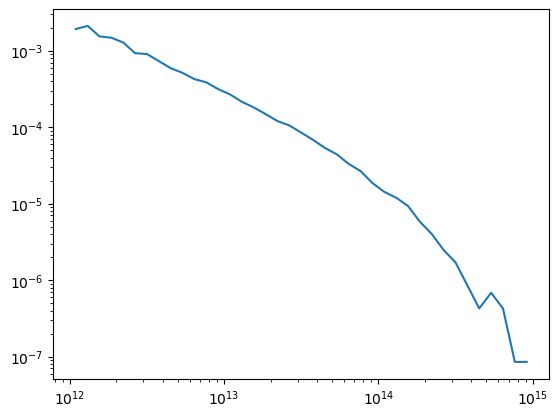

In [131]:
x, y = MassFunc(logm, redshift_real, 0.44, 0.64)
plt.loglog(x,y)
#plt.yscale('log')

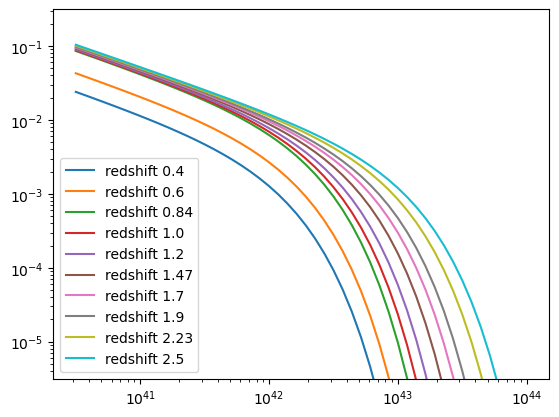

In [38]:
luminosity = 10**np.linspace(40.5, 44)
redshift = [0.4, 0.6, 0.84, 1.0, 1.2, 1.47, 1.7, 1.9, 2.23, 2.5]
for z in redshift:
    Psi = Ha_LF(z, luminosity)
    plt.loglog(luminosity, Psi, label = f'redshift {z}')
plt.ylim(10**(-5.5), 10**(-0.5))
plt.legend()

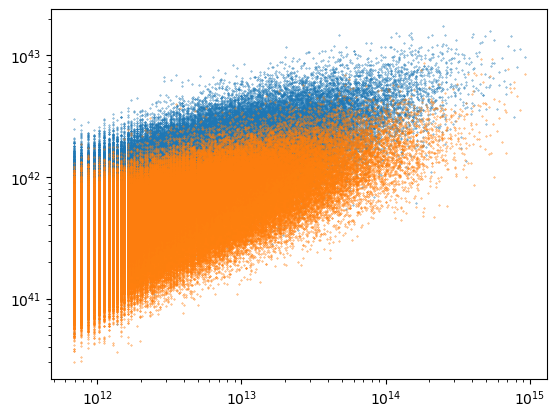

In [119]:
Ha, OIII = AbundanceMatch(logm, redshift_real, 0.2, 0.64)
mass = 10**logm[(redshift_real>0.2)&(redshift_real<0.64)]
plt.scatter(mass, Ha, s=0.1)
plt.scatter(mass, OIII, s=0.1)
plt.xscale('log')
plt.yscale('log')

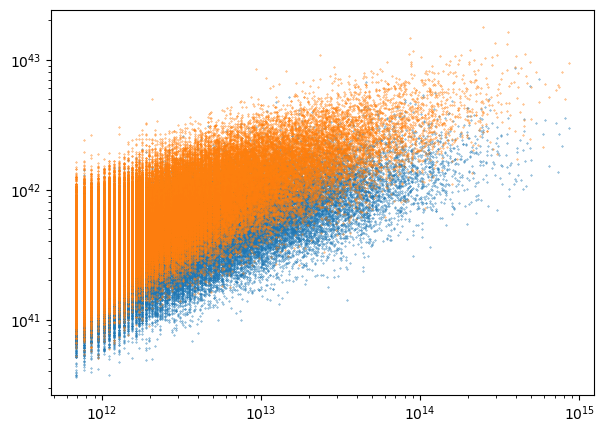

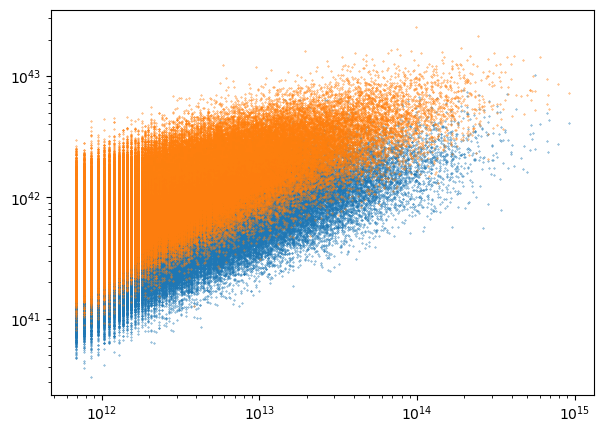

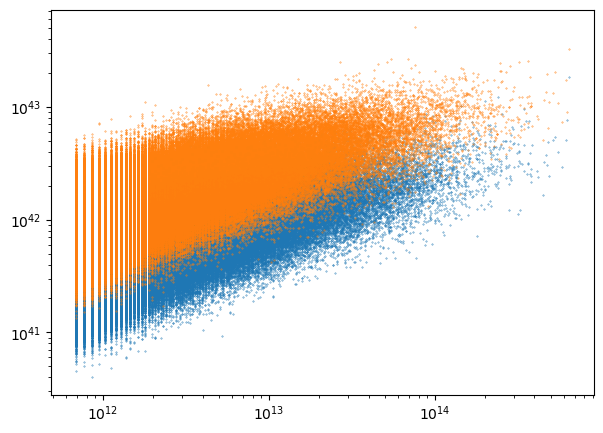

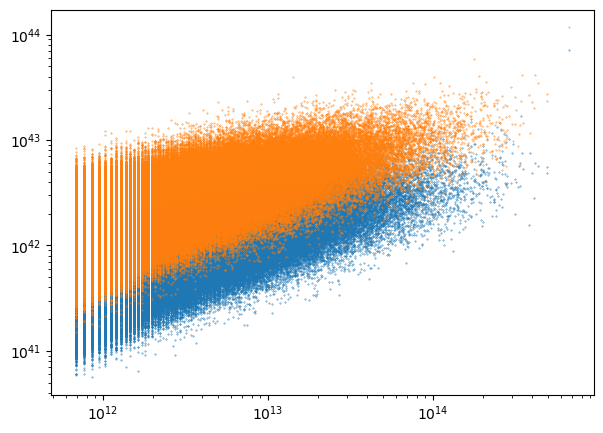

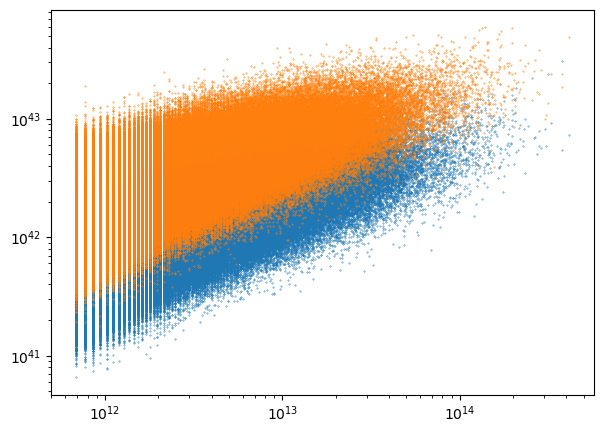

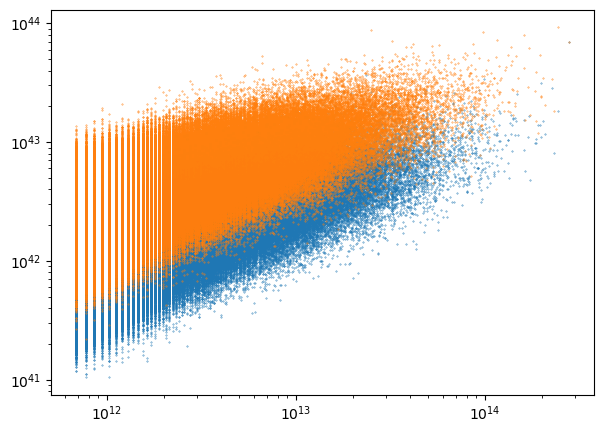

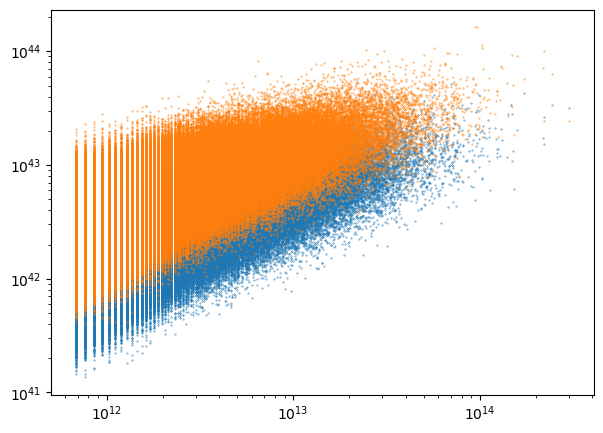

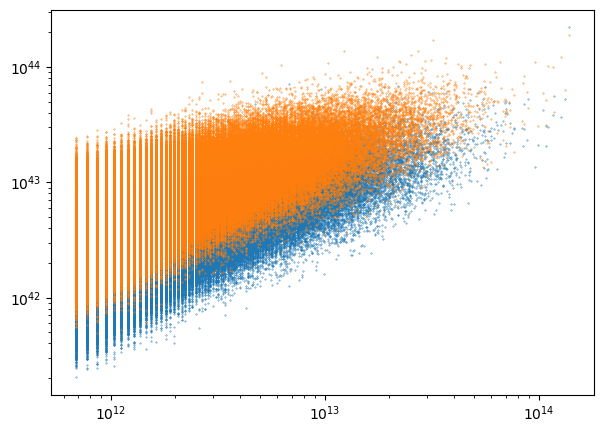

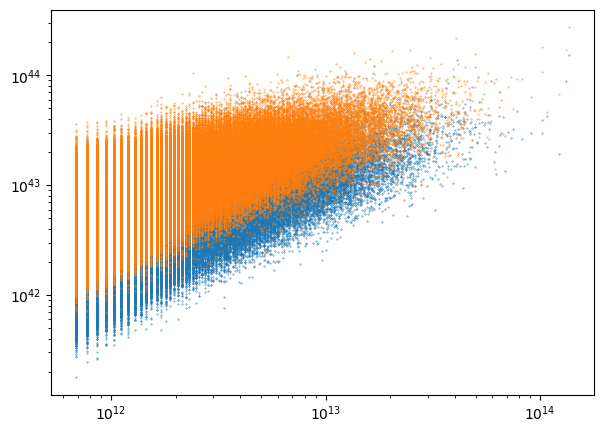

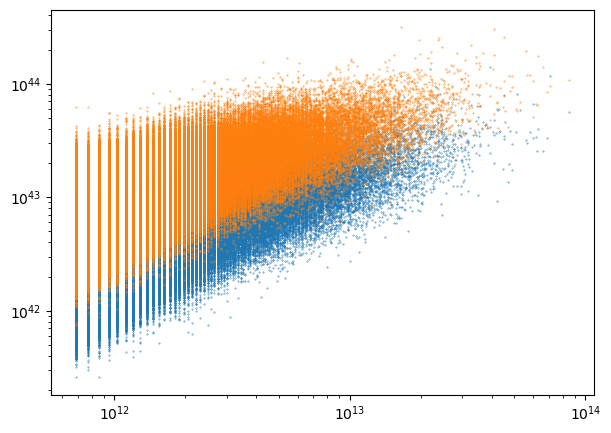

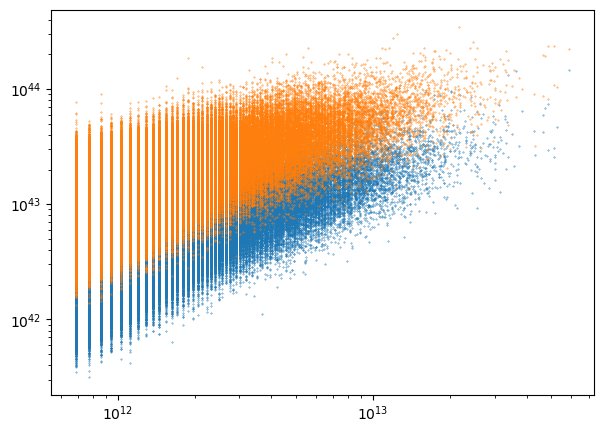

In [134]:
redshift_bin = [0.2, 0.44,  0.64, 0.84, 1.1, 1.45, 1.7, 2.0, 2.25, 2.5, 2.75, 3.0]
Ha = np.zeros(len(logm))
OIII = np.zeros(len(logm))

for i, z in enumerate(redshift_bin):
    if i==0:
        continue
    zmin = redshift_bin[i-1]
    zmax = redshift_bin[i]
    
    _Ha, _OIII = AbundanceMatch(logm, redshift_real, zmin, zmax)
    in_bin = (redshift_real>zmin)&(redshift_real<zmax)
    Ha[in_bin] = _Ha
    OIII[in_bin] = _OIII
    fig = plt.figure(figsize=(7,5))
    plt.scatter(10**logm[in_bin], _OIII, s=0.1)
    plt.scatter(10**logm[in_bin], _Ha, s=0.1)
    plt.xscale('log')
    plt.yscale('log')

In [145]:
import pandas as pd
ra = (pos_x+240)%360
dec = pos_y + 66+ 33.0/60.0 + 38.55/3600.0
range = (redshift_real>0.2)&(redshift_real<3.0)
data = pd.DataFrame({
    'mass':logm[range],
    'ra':pos_x[range],
    'dec':pos_y[range],
    'obsz':redshift_obs[range],
    'truez':redshift_real[range],
    'Ha':Ha[range],
    'OIII':OIII[range]
})

data.to_csv('../output/north_lightcone.txt', index=False)

In [2]:
from create_mock import *

In [3]:
params = Params()
params.Default()

In [3]:
path = '/mnt/data_cat3/yuka/repository/LIM_mock/output/north_lightcone.txt'
total, Ha, OIII = make_mock(path, params)
star, dgl, zodiac, mask, foreground = make_foreground(270.0, 66.56, params)

[3090 3019 3072 ... 5188 4486 6518]


In [15]:
from astropy.io import fits
import numpy as np

# HDU（Header Data Unit）を作成
hdu0 = fits.PrimaryHDU()  # ヘッダーのみ or 最初のデータ
hdu1 = fits.ImageHDU(zodiac, name='ZODIAC')
hdu2 = fits.ImageHDU(dgl, name='DGL')
hdu3 = fits.ImageHDU(star, name='STARS')
hdu4 = fits.ImageHDU(mask*1, name='MASK')

# HDUListにまとめて書き出し
hdul = fits.HDUList([hdu0, hdu1, hdu2, hdu3, hdu4])
hdul.writeto('../output/foregrounds.fits', overwrite=True)


In [4]:
hdu = fits.open('../output/foregrounds.fits')
print(repr(hdu[1].header))
zodiac, dgl, star, mask = hdu[1].data, hdu[2].data, hdu[3].data, hdu[4].data

XTENSION= 'IMAGE   '           / Image extension                                
BITPIX  =                  -64 / array data type                                
NAXIS   =                    3 / number of array dimensions                     
NAXIS1  =                   49                                                  
NAXIS2  =                 8307                                                  
NAXIS3  =                 8307                                                  
PCOUNT  =                    0 / number of parameters                           
GCOUNT  =                    1 / number of groups                               
EXTNAME = 'ZODIAC  '           / extension name                                 


In [5]:
hdu = fits.open('../output/signal.fits')
total, Ha, OIII = hdu[1].data, hdu[2].data, hdu[3].data

In [20]:
# HDU（Header Data Unit）を作成
hdu0 = fits.PrimaryHDU()  # ヘッダーのみ or 最初のデータ
hdu1 = fits.ImageHDU(total, name='TOTAL')
hdu2 = fits.ImageHDU(Ha, name='Halpha')
hdu3 = fits.ImageHDU(OIII, name='OIII')

# HDUListにまとめて書き出し
hdul = fits.HDUList([hdu0, hdu1, hdu2, hdu3])
hdul.writeto('../output/signal.fits', overwrite=True)

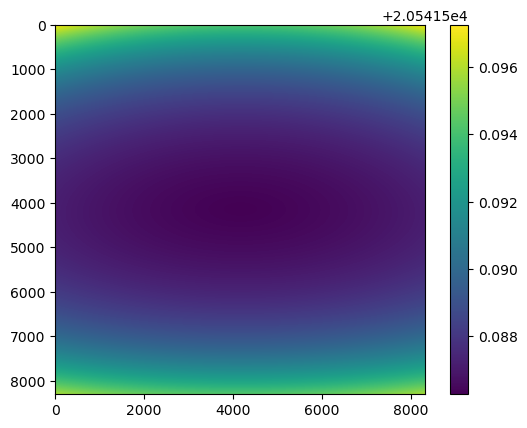

In [19]:
plt.imshow(hdu[1].data[:,:,0])
plt.colorbar()

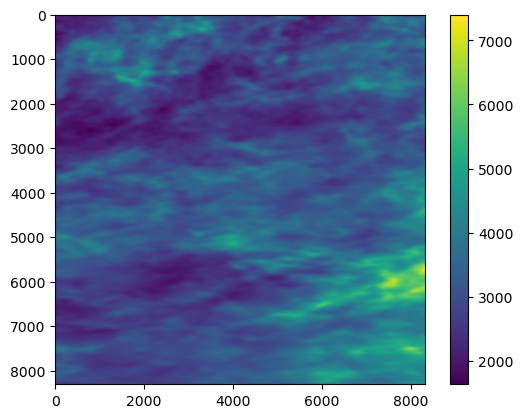

In [7]:
plt.imshow(dgl[:,:,0])
plt.colorbar()

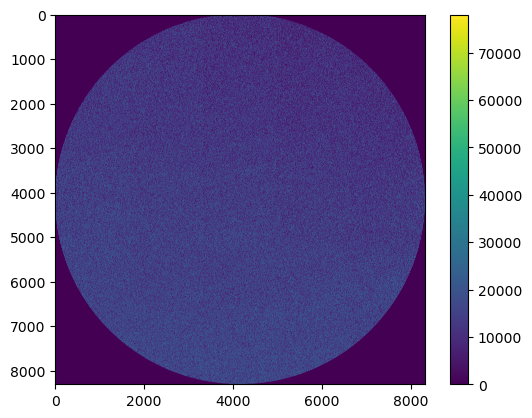

In [10]:
foreground = (zodiac + dgl + star) * mask[:, :, np.newaxis]
plt.imshow(foreground[:,:,0])
plt.colorbar()

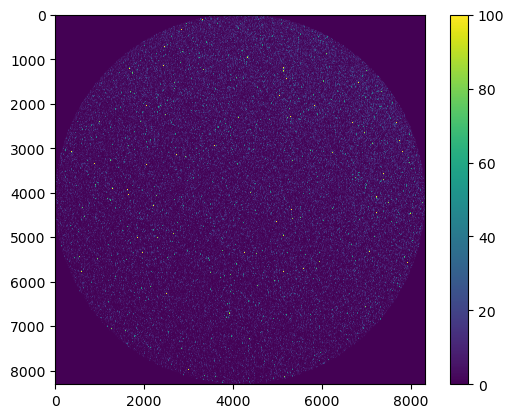

In [4]:
from scipy.ndimage import gaussian_filter
#image = gaussian_filter(star[:,:,0], sigma=0.3, mode='reflect')
plt.imshow(star[:,:,0], vmax=1e2)
plt.colorbar()

In [6]:
from numpy.fft import fftn, fftfreq
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
from scipy.interpolate import interp1d
import sys

import astropy.cosmology
from astropy.cosmology import Planck18 as cosmo
import astropy.units as u

arcmin = 2.908882086656e-4 # [rad] ... PI / 180 / 60 //
arcsec = 4.848136811094e-6 # [rad] ... arcmin / 60 //
GHz = 1e9

def arcsec_to_cMpc(l_arcsec, z):
    l_rad = l_arcsec * u.arcsec / u.radian
    l_cMpc = ( cosmo.comoving_transverse_distance(z) * l_rad ).to(u.Mpc)
    return l_cMpc.value 

def freq_to_comdis(nu_obs, nu_rest):
    z = nu_rest / nu_obs - 1
    if z < 0:
        print("Error: z < 0")
        sys.exit(1)
    return cosmo.comoving_distance(z).to(u.Mpc).value

In [7]:
def my_fft(X, L=None, b=1.): # b = 2 * np.pi for inverse FT
    """
    Actually whatever dimension is ok
    input:
        X: (Nx, Ny, Nz) data 
        L: (3,) or float, box size
        b: normalization factor
    output:
        ft: (Nx, Ny, Nz) Fourier transform
        freq: (Nx, Ny, Nz) frequency
    """

    dim = len(X.shape)
    N = np.array(X.shape)

    if L is None:
        L = N
    elif np.isscalar(L):
        L = L * np.ones(dim)

    dx = np.array([float(l)/float(n) for l, n in zip(L, N)])
    Vx = np.prod(dx) # volume of a cell

    freq = [fftfreq(n, d=d)*2*np.pi for n, d in zip(N, dx)]
    ft = Vx * fftn(X) * np.sqrt(1/np.abs(b)) ** dim
    
    return ft, freq

def calc_power(freq_obs, intensity, intensity2=None, side_length=3600, line_name="CO(1-0)", dlogk=0.2, with_hlittle=True, logkpara_min=-10, logkperp_min=-10, sigma_noise=0, sigma_noise2=0): 
    """
    input:
        freq: (N,) frequency [GHz]
        intensity: (Nx, Ny, Nf) intensity [arbitrary unit]
        side_length: side length [arcsec]
        line_name: line name for which the distance is calculated
        dlogk: bin width for logk
        with_hlittle: if True, multiply h
        logkpara_min: minimum value of logkpara
        logkperp_min: minimum value of logkperp
    output:
        k: (Nk,) wavenumber [h/cMpc^-1]
        power1d: (Nk,) power spectrum [input unit^2 * (cMpc/h)^3]
    """
    line_dict = {
        'Halpha':4.856e5*GHz,
        'OIII':5.997e5*GHz
    }
    redshifts = line_dict[line_name]  / GHz/ freq_obs - 1
    redshift_mean = np.mean(redshifts)
    nu_rest = line_dict[line_name] / GHz

    print("Use {} rest-frame frequency".format(line_name))
    print("redshift: {:.2f} - {:.2f} (mean: {:.2f})".format(redshifts[-1],redshifts[0],redshift_mean))
    
    Lx = arcsec_to_cMpc(side_length, redshift_mean) # [cMpc]
    Ly = arcsec_to_cMpc(side_length, redshift_mean) # [cMpc]
    Lz = freq_to_comdis(freq_obs[0], nu_rest) - freq_to_comdis(freq_obs[-1], nu_rest) # [cMpc]

    ## Fourier transform
    L = np.array([Lx, Ly, Lz])
    dL = np.array([Lx / intensity.shape[0], Ly / intensity.shape[1], Lz / intensity.shape[2]])
    hlittle = cosmo.H0.value / 100
    if with_hlittle:
        L *= hlittle # [cMpc/h]
        dL *= hlittle # [cMpc/h]
    V = np.prod(L) 
    dV = np.prod(dL) # [cMpc/h]^3
    
    ft, freq = my_fft(intensity, L=L)
    if intensity2 is None:
        ft2 = ft
    else:
        ft2, freq2 = my_fft(intensity2, L=L)

    power_spectrum = np.real(ft* np.conj(ft2)) / V
    kx, ky, kz = np.meshgrid(freq[0], freq[1], freq[2], indexing='ij')

    ## noise power spectrum
    power_noise = sigma_noise**2 * dV

    ## compute angular-averaged power spectrum
    logk = np.log10(np.sqrt(kx**2 + ky**2 + kz**2))
    logkpara = np.log10(np.abs(kz))
    logkperp = np.log10(np.sqrt(kx**2 + ky**2))
    
    logk_bins = np.arange(-1.4, 1.3, dlogk)#dk=k*dlogk
    
    power1d = np.zeros(len(logk_bins) - 1)
    power1d_err = np.zeros(len(logk_bins) - 1)
    for i in range(len(logk_bins) - 1):
        mask = (logk >= logk_bins[i]) & (logk < logk_bins[i+1]) & (logkpara > logkpara_min) & (logkperp > logkperp_min)
        Nk = mask.sum()

        if np.any(mask):
            power1d[i] = np.mean(power_spectrum[mask])
            power1d_err[i] = (power1d[i] + power_noise) / np.sqrt(Nk)

    return 10**(0.5*(logk_bins[1:]+logk_bins[:-1])), power1d, power1d_err

In [8]:
from scipy.sparse import diags
from scipy import sparse
from scipy.sparse.linalg import spsolve

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.linear_model import Ridge
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

import torch
from torch.utils.data import TensorDataset, DataLoader
import torch.nn as nn
import copy

import pandas as pd

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class Foreground(object):

    def __init__(self, data, mask):
        self.data = data
        self.mask = mask
        self.subtracted = None
        self.foreground = None

    def PCA(self, n_comp):
        mask_flat = self.mask
        mask_flat = mask_flat.flatten()
        
        data = self.data
        size = data.shape
        X_p_nu = data.reshape(-1, size[2])
        X_p_nu = X_p_nu[mask_flat>0]
        mu_p = np.average(X_p_nu, axis=1) #mean
        tilda_X_p_nu = X_p_nu - mu_p[:, np.newaxis]
        pca = PCA(n_components=n_comp)
        foreground = (pca.inverse_transform(pca.fit_transform(tilda_X_p_nu)) +  mu_p[:, np.newaxis])
        residual = X_p_nu - foreground

        Nz = size[2]
        residual_mask = np.zeros_like(data, dtype=np.float32)
        foreground_mask = np.zeros_like(data, dtype=np.float32)
        for i in range(Nz):
            residual_ = np.zeros_like(mask_flat, dtype=np.float32)
            foreground_ = np.zeros_like(mask_flat, dtype=np.float32)

            # foreground[0, :] を mask=True の場所に代入
            residual_[mask_flat>0] = residual[:,i]  # 周波数インデックス 0 の例
            foreground_[mask_flat>0] = foreground[:,i]

            # 元の形状に戻す
            residual_mask[:,:,i] = residual_.reshape(mask.shape)
            foreground_mask[:,:,i] = foreground_.reshape(mask.shape)
        self.subtracted = residual_mask
        self.foreground = foreground_mask

    def PCA_space(self, n_comp):
        data = self.data  # shape = (Ny, Nx, Nz)
        mask = self.mask  # shape = (Ny, Nx)

        Ny, Nx, Nz = data.shape
        mask_flat = mask.flatten()  # shape = (Ny*Nx,)

        # reshape: (Nz, Ny, Nx) → (Nz, Ny*Nx)
        X_p_nu = data.transpose(2, 0, 1).reshape(Nz, -1)  # shape = (Nz, Npix)
        X_p_nu_masked = X_p_nu[:, mask_flat > 0]          # shape = (Nz, N_valid_pix)

        # 平均をスペクトル方向に対してとる
        mu_p = np.mean(X_p_nu_masked, axis=1, keepdims=True)  # shape = (Nz, 1)
        tilda_X_p_nu = X_p_nu_masked - mu_p                   # demean

        # PCA (空間構造の主成分抽出)
        pca = PCA(n_components=n_comp)
        transformed = pca.fit_transform(tilda_X_p_nu.T)        # shape = (N_valid_pix, n_comp)
        foreground = pca.inverse_transform(transformed).T + mu_p  # shape = (Nz, N_valid_pix)

        # 残差
        residual = X_p_nu_masked - foreground

        # 空間マップに戻す
        residual_cube = np.zeros((Nz, Ny*Nx), dtype=np.float32)
        foreground_cube = np.zeros((Nz, Ny*Nx), dtype=np.float32)
        residual_cube[:, mask_flat > 0] = residual
        foreground_cube[:, mask_flat > 0] = foreground

        # reshape back to (Ny, Nx, Nz)
        self.subtracted = residual_cube.reshape(Nz, Ny, Nx).transpose(1, 2, 0)
        self.foreground = foreground_cube.reshape(Nz, Ny, Nx).transpose(1, 2, 0)


    def alPLS(self, lambda_, sigma_noise, ratio=1e-6, max_iter=100):
        mask_flat = self.mask
        mask_flat = mask_flat.flatten()
        
        data = self.data
        size = data.shape
        X_p_nu = data.reshape(-1, size[2])
        masked_data = X_p_nu[mask_flat>0]

        pixel = np.sum(mask_flat)

        L = size[2]
        D = sparse.diags([1, -2, 1], [0, 1, 2], shape=(L-2, L)).tocsc()
        H = lambda_ * (D.T @ D)

        residual_ = np.zeros_like(X_p_nu, dtype=np.float32)
        for i in range(pixel):
            w = np.ones(L)
            spectro = masked_data[i]
            for i in range(max_iter):
                W = sparse.diags(w, 0)
                Z = W + H
                z = spsolve(Z, w * spectro)
                d = spectro - z
                dn = d[d < 0]
                m = 0
                s = sigma_noise
                w_new = (d>0) / (1 + np.exp(2 * (d - (2*s - m)) / s)) + (d<0)
                if np.linalg.norm(w - w_new) / np.linalg.norm(w) < ratio:
                    break
                w = w_new
            residual = spectro - z
            residual_[mask_flat>0][i] = residual
        
        self.subtracted = residual_.reshape(size)

    def AutoNN(self, num_epochs, sigma):
        data = self.data

        mask = self.mask
        mask_flat = mask.flatten()

        shape = np.shape(data)
        data_flat = data.reshape(-1, shape[2])
        data_masked = data_flat[mask_flat>0]

        train, temp = train_test_split(data_masked, test_size=0.2)
        val, test = train_test_split(temp, test_size=0.5)

        # Convert to torch tensors
        data_tensor = torch.tensor(data_masked, dtype=torch.float32)
        train_tensor = torch.tensor(train, dtype=torch.float32)
        val_tensor = torch.tensor(val, dtype=torch.float32)
        test_tensor = torch.tensor(test, dtype=torch.float32)

        dataset = TensorDataset(train_tensor)
        loader = DataLoader(dataset, batch_size=128, shuffle=True)

        model = ForegroundAutoencoder(n_freq=shape[2]).to(device)

        optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

        patience=20
        best_val_loss = float('inf')
        trigger_times = 0
        best_model = copy.deepcopy(model)
        loss_list = []

        signal_masked = np.zeros_like(data_flat)

        for epoch in range(num_epochs):
            model.train()
            for _data in loader:
                input_batch = _data[0].to(device)
                
                output = model(input_batch)
                loss, logs = foreground_loss(input_batch, output, sigma, alpha=1e1)

                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            # Validation
            model.eval()
            with torch.no_grad():
                val_tensor_device = val_tensor.to(device)
                val_output = model(val_tensor_device)
                val_loss, _ = foreground_loss(val_tensor_device, val_output, sigma, alpha=1e1)

                test_tensor_device = test_tensor.to(device)
                test_output = model(test_tensor_device)
                test_loss, _ = foreground_loss(test_tensor_device, test_output, sigma, alpha=1e1)
                loss_list.append(test_loss.item())

            print(f"[{epoch}] val_loss: {val_loss.item():.6f}")

            # Early stopping check
            if val_loss.item() < best_val_loss:
                best_val_loss = val_loss.item()
                best_model = copy.deepcopy(model)
                trigger_times = 0
            else:
                trigger_times += 1
                if trigger_times >= patience:
                    print(f"Early stopping triggered at epoch {epoch}")
                    break

        data_tensor_device = data_tensor.to(device)
        subtracted = (data_masked - best_model(data_tensor_device).cpu().detach().numpy())

        signal_masked[mask_flat>0] = subtracted
        signal_masked = signal_masked.reshape(shape)

        self.subtracted = signal_masked
        epoch_list = np.arange(len(loss_list))
        plt.plot(epoch_list, loss_list)
        plt.yscale('log')
        plt.xlabel("Epoch")
        plt.ylabel("Test Loss (log scale)")


class ForegroundAutoencoder(nn.Module):
    def __init__(self, n_freq):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(n_freq, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Linear(256, 32),
            nn.BatchNorm1d(32),
            nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.Linear(32, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Linear(256, n_freq)
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))



def curvature_loss(output):
    """
    Curvature (2nd derivative) regularization loss.
    Encourages smooth frequency structure.
    """
    return torch.mean((output[:, 2:] - 2 * output[:, 1:-1] + output[:, :-2])**2)

def foreground_loss(input, output, sigma, alpha=1e1, gamma=2.0):
    """
    Combined loss for foreground autoencoder:
    - MSE with dynamic weights (to avoid strong signals)
    - Curvature loss for smoothness
    - Residual sparsity loss
    """
    residual = input - output

    # Soft mask: smoothly downweight residuals > 2σ
    weight = torch.exp(-gamma * torch.relu(residual - 2 * sigma) / sigma)

    # Loss terms
    weighted_mse = torch.mean(weight * residual**2)

    smoothness = curvature_loss(output)

    total_loss = weighted_mse + alpha * smoothness
    return total_loss, {'mse': weighted_mse.item(), 'smooth': smoothness.item()}

def Weights(dgl_map, flux, mask, sigma):
    shape = flux.shape
    mask_flat = mask.flatten()
    flux_flat = flux.reshape(-1, shape[2])
    foreground = np.zeros_like(flux_flat, dtype=np.float32)
    mean = np.mean(flux_flat, axis=0)
    outlier_mask = np.abs(flux_flat - mean) > 3 * sigma  # shape: (N_pixels, N_band)

    # どれか1バンドでも3σを超えていたら、その行は除外対象
    remove_row_mask = ~np.any(outlier_mask, axis=1)
    selection = (mask_flat>0)&remove_row_mask

    dgl = dgl_map.flatten()[selection].astype(np.float32)
    flux_sel = flux_flat[selection].astype(np.float32)

    # Normalize DGL
    dgl_mean, dgl_std = np.mean(dgl), np.std(dgl)
    dgl_norm = (dgl - dgl_mean) / dgl_std
    dgl_all = (dgl_map.flatten()[mask_flat > 0].astype(np.float32) - dgl_mean) / dgl_std

    # Train-validation-test split
    trainX, tempX, trainY, tempY = train_test_split(dgl_norm.reshape(-1, 1), flux_sel, test_size=0.2)
    valX, testX, valY, testY = train_test_split(tempX, tempY)

    # Convert to torch.Tensor with safe byte order
    def to_tensor(arr):
        return torch.tensor(np.ascontiguousarray(arr), dtype=torch.float32)

    trainX, trainY = to_tensor(trainX), to_tensor(trainY).unsqueeze(1)
    valX, valY = to_tensor(valX), to_tensor(valY).unsqueeze(1)
    testX, testY = to_tensor(testX), to_tensor(testY).unsqueeze(1)
    X_all = to_tensor(dgl_all.reshape(-1, 1))

    # Define smaller model
    model = torch.nn.Sequential(
        torch.nn.Linear(1, 16),
        nn.BatchNorm1d(16),
        torch.nn.ReLU(),
        torch.nn.Linear(16, 16),
        nn.BatchNorm1d(16),
        torch.nn.ReLU(),
        torch.nn.Linear(16, 48)
    )

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
    loss_fn = torch.nn.MSELoss()
    best_model = copy.deepcopy(model)
    best_val_loss = float('inf')
    trigger_times = 0
    patience = 10

    for epoch in range(300):  # reduce max epochs
        model.train()
        pred = model(trainX)
        loss = loss_fn(pred, trainY)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            val_loss = loss_fn(model(valX), valY).item()
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_model = copy.deepcopy(model)
                trigger_times = 0
            else:
                trigger_times += 1
                if trigger_times >= patience:
                    print(f"Early stopping at epoch {epoch}")
                    break

    model = best_model
    with torch.no_grad():
        Y_all = model(X_all).numpy().flatten()

    foreground[mask_flat > 0] = Y_all
    foreground = foreground.reshape(shape)

    return flux - foreground


from sklearn.linear_model import Ridge

def WeightsFast(dgl_map, flux, mask, sigma, alpha=1.0, degree=2):
    shape = flux.shape
    mask_flat = mask.flatten()
    residual = np.zeros_like(flux)

    for f in range(shape[2]):
        flux_flat = flux[:, :, f].flatten()
        selection = (flux_flat < 2.4 * sigma) & (flux_flat > -2.5 * sigma) & (mask_flat > 0)

        dgl = dgl_map.flatten()[selection]
        dgl_mean = np.average(dgl)
        dgl_std = np.std(dgl)
        dgl_ = (dgl - dgl_mean)/dgl_std
        #zod = zod_map.flatten()[selection]
        flux_sel = flux_flat[selection]

        dgl_all = dgl_map.flatten()[mask_flat > 0]
        dgl_all = (dgl_all - dgl_mean)/dgl_std
        #zod_all = zod_map.flatten()[mask_flat > 0]

        #X = np.stack([dgl_, zod], axis=1)
        X=dgl_.reshape(-1, 1)
        #X_all = np.stack([dgl_all, zod_all], axis=1)
        X_all = dgl_all.reshape(-1, 1)

        model = make_pipeline(PolynomialFeatures(degree=degree, include_bias=True),
                              Ridge(alpha=alpha))
        model.fit(X, flux_sel)
        y_pred = model.predict(X_all)

        residual_flat = np.zeros_like(mask_flat, dtype=np.float32)
        residual_flat[mask_flat > 0] = y_pred
        residual[:, :, f] = residual_flat.reshape(shape[0], shape[1])

    return flux - residual



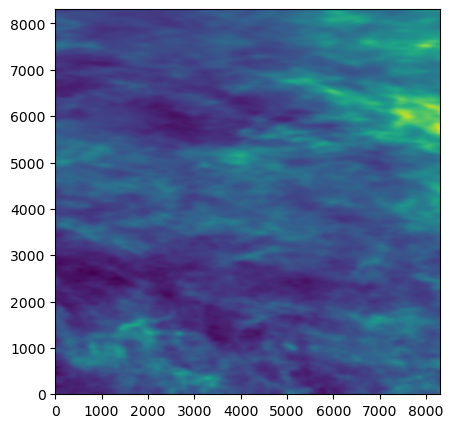

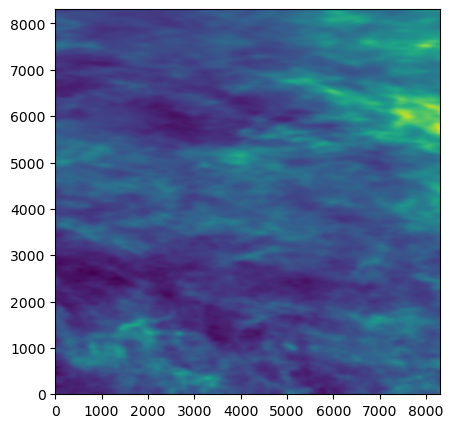

In [9]:
import healpy as hp
from astropy.coordinates import SkyCoord

def GetEBV (Nx, ramin, ramax, decmin, decmax):
    ebv_map = hp.read_map("/mnt/data_cat3/yuka/data/LIM_mock/csfd_ebv.fits")
    nside = hp.get_nside(ebv_map)

    # ベクトルでRA/Dec配列を生成
    ra_grid, dec_grid = np.meshgrid(
        np.linspace(ramin, ramax, Nx),
        np.linspace(decmin, decmax, Nx)
    )
    ra_flat = ra_grid.ravel()
    dec_flat = dec_grid.ravel()

    coords = SkyCoord(ra=ra_flat * u.deg, dec=dec_flat * u.deg, frame='icrs')
    gal_coords = coords.galactic
    l = gal_coords.l.deg
    b = gal_coords.b.deg
    pix = hp.ang2pix(nside, l, b, lonlat=True)

    ebv_vals = ebv_map[pix]  # convert to mag
    ebv_vals = ebv_vals.reshape(Nx, Nx)  # shape: (Nx, Nx, 1)

    return ebv_vals

import numpy as np
EBV = GetEBV(np.shape(total)[0], 262.5, 277.5, 59.06, 74.06)
fig = plt.figure(figsize=(5,5))
plt.imshow(EBV, origin='lower')
fig = plt.figure(figsize=(5,5))
plt.imshow(dgl[:,:,0], origin='lower')

In [13]:
from numpy.fft import fft2, ifft2, fftshift
from sklearn.decomposition import PCA

hdu = fits.open('../output/signal.fits')
signal = hdu[1].data
hdu.close()

hdu = fits.open('../output/foregrounds.fits')
zodiac = hdu[1].data
dgl = hdu[2].data
star = hdu[3].data
mask = hdu[4].data
hdu.close()

Obs = (signal + star + dgl + zodiac)
Obs = gaussian_filter(Obs, sigma=(0.3, 0.3, 0))

f_nu = 0.2*3631*10**(-0.4*22)
dtheta = 6.5
sigma_noise = f_nu / (dtheta * arcsec)**2 # [Jy/sr]
#noise_intensity = np.random.normal(0, sigma_noise, intensity.shape) * mask[:, :, np.newaxis]

# ノイズは mask せずに生成
noise = np.random.normal(0, sigma_noise, Obs.shape)

# galaxy と noise をそれぞれ平滑化
smoothed_galaxy = gaussian_filter(signal, sigma=(0.3, 0.3, 0))
smoothed_noise = noise

# mask は最後に掛ける
galaxy_mask = smoothed_galaxy * mask[:, :, np.newaxis]
galaxy_noise_mask = (smoothed_galaxy + smoothed_noise) * mask[:, :, np.newaxis]

total = (Obs + smoothed_noise)* mask[:, :, np.newaxis]

foreground = Foreground(total, mask)
foreground.PCA(3)
pca_signal = foreground.subtracted

#foreground = Foreground(pca_signal, mask)
#foreground.AutoNN(200, sigma_noise)
#AutoNN_signal = foreground.subtracted

#foreground = Foreground(total, mask)
#foreground.alPLS(1e0, sigma_noise)
#alpls_signal = foreground.subtracted

#galaxy = (intensity)
#noise = noise_intensity
#galaxy_mask = gaussian_filter(galaxy, sigma=(0.3, 0.3, 0)) * mask[:, :, np.newaxis]
#galaxy_noise_mask = (gaussian_filter(galaxy, sigma=(0.3, 0.3, 0)) + noise) * mask[:, :, np.newaxis]

########################################### zodiacal light
zodiacal_mask = gaussian_filter(zodiac, sigma=(0.3, 0.3, 0)) * mask[:, :, np.newaxis]

########################################### star light
star_mask = gaussian_filter(star, sigma=(0.3, 0.3, 0)) * mask[:, :, np.newaxis]

########################################### DGL
dgl_mask = gaussian_filter(dgl, sigma=(0.3, 0.3, 0)) * mask[:, :, np.newaxis]

#foreground = Foreground(pca_signal, mask)
#foreground.Weights(EBV, flux, mask)
#weighted_map = foreground.subtracted
#weighted_map = Weights(EBV, pca_signal, mask, sigma_noise)
weighted_map = WeightsFast(EBV, pca_signal, mask, sigma_noise, degree=2)

In [11]:
params = Params()
params.Default()
freq, dflist = frequency(params)
side_length = params.radius*2.0*3600.0
freq /= 1e9

Use Halpha rest-frame frequency
redshift: 0.24 - 3.05 (mean: 1.38)


/tmp/ipykernel_1501969/1158523987.py:82: RuntimeWarning: divide by zero encountered in log10
  logk = np.log10(np.sqrt(kx**2 + ky**2 + kz**2))
/tmp/ipykernel_1501969/1158523987.py:83: RuntimeWarning: divide by zero encountered in log10
  logkpara = np.log10(np.abs(kz))
/tmp/ipykernel_1501969/1158523987.py:84: RuntimeWarning: divide by zero encountered in log10
  logkperp = np.log10(np.sqrt(kx**2 + ky**2))


Use Halpha rest-frame frequency
redshift: 0.24 - 3.05 (mean: 1.38)
Use Halpha rest-frame frequency
redshift: 0.24 - 3.05 (mean: 1.38)
Use Halpha rest-frame frequency
redshift: 0.24 - 3.05 (mean: 1.38)
Use Halpha rest-frame frequency
redshift: 0.24 - 3.05 (mean: 1.38)
Use Halpha rest-frame frequency
redshift: 0.24 - 3.05 (mean: 1.38)
Use Halpha rest-frame frequency
redshift: 0.24 - 3.05 (mean: 1.38)
Use Halpha rest-frame frequency
redshift: 0.24 - 3.05 (mean: 1.38)
Use Halpha rest-frame frequency
redshift: 0.24 - 3.05 (mean: 1.38)


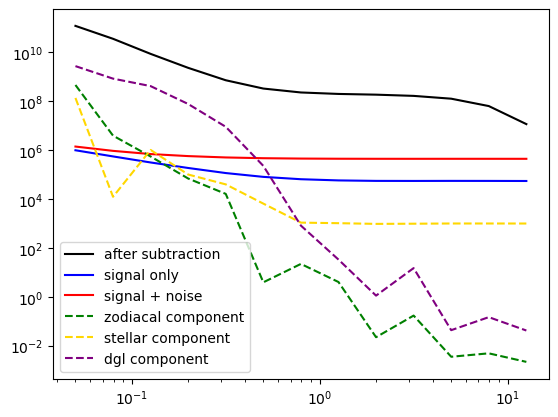

In [14]:
k, power, power_err = calc_power(freq, total, intensity2=total, side_length=side_length, line_name="Halpha", dlogk=0.2, with_hlittle=True, logkpara_min=-10, logkperp_min=-10, sigma_noise=0, sigma_noise2=0)
plt.plot(k, power, color='black', label='after subtraction')
k, power, power_err = calc_power(freq, galaxy_mask, intensity2=galaxy_mask, side_length=side_length, line_name="Halpha", dlogk=0.2, with_hlittle=True, logkpara_min=-10, logkperp_min=-10, sigma_noise=0, sigma_noise2=0)
plt.plot(k, power, color='blue', label='signal only')
k, power, power_err = calc_power(freq, galaxy_noise_mask, intensity2=galaxy_noise_mask, side_length=side_length, line_name="Halpha", dlogk=0.2, with_hlittle=True, logkpara_min=-10, logkperp_min=-10, sigma_noise=0, sigma_noise2=0)
plt.plot(k, power, color='red', label='signal + noise')

k1, power1, power_err1 = calc_power(freq, zodiacal_mask, intensity2=zodiacal_mask, side_length=side_length, line_name="Halpha", dlogk=0.2, with_hlittle=True, logkpara_min=-10, logkperp_min=-10, sigma_noise=0, sigma_noise2=0)
k, power, power_err = calc_power(freq, Obs, intensity2=zodiacal_mask, side_length=side_length, line_name="Halpha", dlogk=0.2, with_hlittle=True, logkpara_min=-10, logkperp_min=-10, sigma_noise=0, sigma_noise2=0)
plt.plot(k, power**2/power1, color='green', label='zodiacal component',linestyle='--')

k, power1, power_err = calc_power(freq, star_mask, intensity2=star_mask, side_length=side_length, line_name="Halpha", dlogk=0.2, with_hlittle=True, logkpara_min=-10, logkperp_min=-10, sigma_noise=0, sigma_noise2=0)
k, power, power_err = calc_power(freq, Obs, intensity2=star_mask, side_length=side_length, line_name="Halpha", dlogk=0.2, with_hlittle=True, logkpara_min=-10, logkperp_min=-10, sigma_noise=0, sigma_noise2=0)
plt.plot(k, power**2/power1, color='gold', label='stellar component',linestyle='--')

k, power1, power_err = calc_power(freq, dgl_mask, intensity2=dgl_mask, side_length=side_length, line_name="Halpha", dlogk=0.2, with_hlittle=True, logkpara_min=-10, logkperp_min=-10, sigma_noise=0, sigma_noise2=0)
k, power, power_err = calc_power(freq, Obs, intensity2=dgl_mask, side_length=side_length, line_name="Halpha", dlogk=0.2, with_hlittle=True, logkpara_min=-10, logkperp_min=-10, sigma_noise=0, sigma_noise2=0)
plt.plot(k, power**2/power1, color='purple', label='dgl component',linestyle='--')

plt.legend()
plt.yscale('log')
plt.xscale('log')

Use Halpha rest-frame frequency
redshift: 0.24 - 3.05 (mean: 1.38)


/tmp/ipykernel_1501969/1158523987.py:82: RuntimeWarning: divide by zero encountered in log10
  logk = np.log10(np.sqrt(kx**2 + ky**2 + kz**2))
/tmp/ipykernel_1501969/1158523987.py:83: RuntimeWarning: divide by zero encountered in log10
  logkpara = np.log10(np.abs(kz))
/tmp/ipykernel_1501969/1158523987.py:84: RuntimeWarning: divide by zero encountered in log10
  logkperp = np.log10(np.sqrt(kx**2 + ky**2))


Use Halpha rest-frame frequency
redshift: 0.24 - 3.05 (mean: 1.38)
Use Halpha rest-frame frequency
redshift: 0.24 - 3.05 (mean: 1.38)
Use Halpha rest-frame frequency
redshift: 0.24 - 3.05 (mean: 1.38)
Use Halpha rest-frame frequency
redshift: 0.24 - 3.05 (mean: 1.38)
Use Halpha rest-frame frequency
redshift: 0.24 - 3.05 (mean: 1.38)
Use Halpha rest-frame frequency
redshift: 0.24 - 3.05 (mean: 1.38)
Use Halpha rest-frame frequency
redshift: 0.24 - 3.05 (mean: 1.38)
Use Halpha rest-frame frequency
redshift: 0.24 - 3.05 (mean: 1.38)


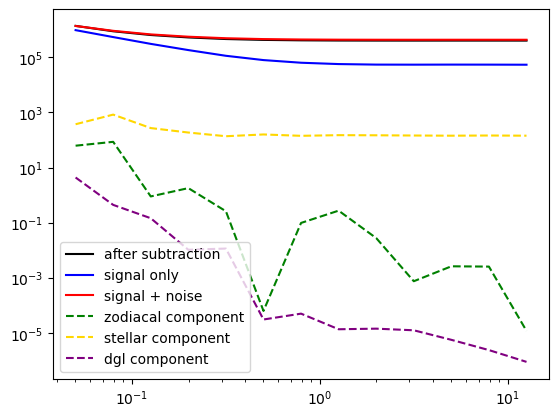

In [15]:
k, power, power_err = calc_power(freq, pca_signal, intensity2=pca_signal, side_length=side_length, line_name="Halpha", dlogk=0.2, with_hlittle=True, logkpara_min=-10, logkperp_min=-10, sigma_noise=0, sigma_noise2=0)
plt.plot(k, power, color='black', label='after subtraction')
k, power, power_err = calc_power(freq, galaxy_mask, intensity2=galaxy_mask, side_length=side_length, line_name="Halpha", dlogk=0.2, with_hlittle=True, logkpara_min=-10, logkperp_min=-10, sigma_noise=0, sigma_noise2=0)
plt.plot(k, power, color='blue', label='signal only')
k, power, power_err = calc_power(freq, galaxy_noise_mask, intensity2=galaxy_noise_mask, side_length=side_length, line_name="Halpha", dlogk=0.2, with_hlittle=True, logkpara_min=-10, logkperp_min=-10, sigma_noise=0, sigma_noise2=0)
plt.plot(k, power, color='red', label='signal + noise')

k1, power1, power_err1 = calc_power(freq, zodiacal_mask, intensity2=zodiacal_mask, side_length=side_length, line_name="Halpha", dlogk=0.2, with_hlittle=True, logkpara_min=-10, logkperp_min=-10, sigma_noise=0, sigma_noise2=0)
k, power, power_err = calc_power(freq, pca_signal, intensity2=zodiacal_mask, side_length=side_length, line_name="Halpha", dlogk=0.2, with_hlittle=True, logkpara_min=-10, logkperp_min=-10, sigma_noise=0, sigma_noise2=0)
plt.plot(k, power**2/power1, color='green', label='zodiacal component',linestyle='--')

k, power1, power_err = calc_power(freq, star_mask, intensity2=star_mask, side_length=side_length, line_name="Halpha", dlogk=0.2, with_hlittle=True, logkpara_min=-10, logkperp_min=-10, sigma_noise=0, sigma_noise2=0)
k, power, power_err = calc_power(freq, pca_signal, intensity2=star_mask, side_length=side_length, line_name="Halpha", dlogk=0.2, with_hlittle=True, logkpara_min=-10, logkperp_min=-10, sigma_noise=0, sigma_noise2=0)
plt.plot(k, power**2/power1, color='gold', label='stellar component',linestyle='--')

k, power1, power_err = calc_power(freq, dgl_mask, intensity2=dgl_mask, side_length=side_length, line_name="Halpha", dlogk=0.2, with_hlittle=True, logkpara_min=-10, logkperp_min=-10, sigma_noise=0, sigma_noise2=0)
k, power, power_err = calc_power(freq, pca_signal, intensity2=dgl_mask, side_length=side_length, line_name="Halpha", dlogk=0.2, with_hlittle=True, logkpara_min=-10, logkperp_min=-10, sigma_noise=0, sigma_noise2=0)
plt.plot(k, power**2/power1, color='purple', label='dgl component',linestyle='--')

plt.legend()
plt.yscale('log')
plt.xscale('log')

Use Halpha rest-frame frequency
redshift: 0.24 - 3.05 (mean: 1.38)


/tmp/ipykernel_1501969/1158523987.py:82: RuntimeWarning: divide by zero encountered in log10
  logk = np.log10(np.sqrt(kx**2 + ky**2 + kz**2))
/tmp/ipykernel_1501969/1158523987.py:83: RuntimeWarning: divide by zero encountered in log10
  logkpara = np.log10(np.abs(kz))
/tmp/ipykernel_1501969/1158523987.py:84: RuntimeWarning: divide by zero encountered in log10
  logkperp = np.log10(np.sqrt(kx**2 + ky**2))


Use Halpha rest-frame frequency
redshift: 0.24 - 3.05 (mean: 1.38)
Use Halpha rest-frame frequency
redshift: 0.24 - 3.05 (mean: 1.38)
Use Halpha rest-frame frequency
redshift: 0.24 - 3.05 (mean: 1.38)
Use Halpha rest-frame frequency
redshift: 0.24 - 3.05 (mean: 1.38)
Use Halpha rest-frame frequency
redshift: 0.24 - 3.05 (mean: 1.38)
Use Halpha rest-frame frequency
redshift: 0.24 - 3.05 (mean: 1.38)
Use Halpha rest-frame frequency
redshift: 0.24 - 3.05 (mean: 1.38)
Use Halpha rest-frame frequency
redshift: 0.24 - 3.05 (mean: 1.38)
Use Halpha rest-frame frequency
redshift: 0.24 - 3.05 (mean: 1.38)


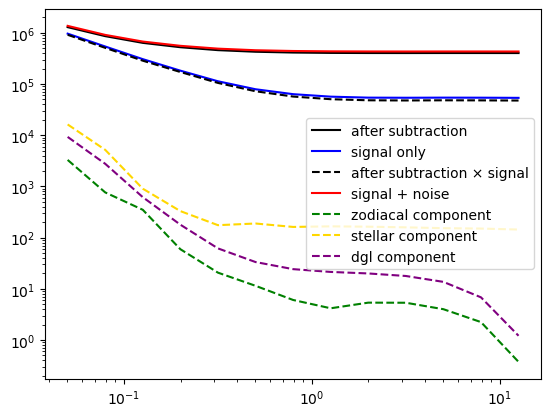

In [16]:
k, power, power_err = calc_power(freq, weighted_map, intensity2=weighted_map, side_length=side_length, line_name="Halpha", dlogk=0.2, with_hlittle=True, logkpara_min=-10, logkperp_min=-10, sigma_noise=0, sigma_noise2=0)
plt.plot(k, power, color='black', label='after subtraction')
k, power, power_err = calc_power(freq, galaxy_mask, intensity2=galaxy_mask, side_length=side_length, line_name="Halpha", dlogk=0.2, with_hlittle=True, logkpara_min=-10, logkperp_min=-10, sigma_noise=0, sigma_noise2=0)
plt.plot(k, power, color='blue', label='signal only')
k, power, power_err = calc_power(freq, galaxy_mask, intensity2=weighted_map, side_length=side_length, line_name="Halpha", dlogk=0.2, with_hlittle=True, logkpara_min=-10, logkperp_min=-10, sigma_noise=0, sigma_noise2=0)
plt.plot(k, power, color='black', label='after subtraction × signal', linestyle='--')
k, power, power_err = calc_power(freq, galaxy_noise_mask, intensity2=galaxy_noise_mask, side_length=side_length, line_name="Halpha", dlogk=0.2, with_hlittle=True, logkpara_min=-10, logkperp_min=-10, sigma_noise=0, sigma_noise2=0)
plt.plot(k, power, color='red', label='signal + noise')

#k, power, power_err = calc_power(freq, galaxy_noise_mask, intensity2=zodiacal_mask, side_length=5400, line_name="Halpha", dlogk=0.2, with_hlittle=True, logkpara_min=-10, logkperp_min=-10, sigma_noise=0, sigma_noise2=0)
k1, power1, power_err1 = calc_power(freq, zodiacal_mask, intensity2=zodiacal_mask, side_length=side_length, line_name="Halpha", dlogk=0.2, with_hlittle=True, logkpara_min=-10, logkperp_min=-10, sigma_noise=0, sigma_noise2=0)
#plt.plot(k, power**2/power1, color='green', label='true zodiacal component')
k, power, power_err = calc_power(freq, weighted_map, intensity2=zodiacal_mask, side_length=side_length, line_name="Halpha", dlogk=0.2, with_hlittle=True, logkpara_min=-10, logkperp_min=-10, sigma_noise=0, sigma_noise2=0)
plt.plot(k, power**2/power1, color='green', label='zodiacal component',linestyle='--')

#k, power, power_err = calc_power(freq, galaxy_noise_mask, intensity2=star_mask, side_length=5400, line_name="Halpha", dlogk=0.2, with_hlittle=True, logkpara_min=-10, logkperp_min=-10, sigma_noise=0, sigma_noise2=0)
k, power1, power_err = calc_power(freq, star_mask, intensity2=star_mask, side_length=side_length, line_name="Halpha", dlogk=0.2, with_hlittle=True, logkpara_min=-10, logkperp_min=-10, sigma_noise=0, sigma_noise2=0)
#plt.plot(k, power**2/power1, color='gold', label='true stellar component')
k, power, power_err = calc_power(freq, weighted_map, intensity2=star_mask, side_length=side_length, line_name="Halpha", dlogk=0.2, with_hlittle=True, logkpara_min=-10, logkperp_min=-10, sigma_noise=0, sigma_noise2=0)
plt.plot(k, power**2/power1, color='gold', label='stellar component',linestyle='--')

#k, power, power_err = calc_power(freq, galaxy_noise_mask, intensity2=dgl_mask, side_length=5400, line_name="Halpha", dlogk=0.2, with_hlittle=True, logkpara_min=-10, logkperp_min=-10, sigma_noise=0, sigma_noise2=0)
k, power1, power_err = calc_power(freq, dgl_mask, intensity2=dgl_mask, side_length=side_length, line_name="Halpha", dlogk=0.2, with_hlittle=True, logkpara_min=-10, logkperp_min=-10, sigma_noise=0, sigma_noise2=0)
#plt.plot(k, power**2/power1, color='purple', label='true dgl component')
k, power, power_err = calc_power(freq, weighted_map, intensity2=dgl_mask, side_length=side_length, line_name="Halpha", dlogk=0.2, with_hlittle=True, logkpara_min=-10, logkperp_min=-10, sigma_noise=0, sigma_noise2=0)
plt.plot(k, power**2/power1, color='purple', label='dgl component',linestyle='--')

plt.legend()
plt.yscale('log')
plt.xscale('log')

In [35]:
freq/1e9

array([120000.  , 122926.83, 125925.05, 128996.39, 132142.64, 135365.64,
       138667.23, 142049.36, 145513.98, 149063.1 , 152698.78, 156423.14,
       160238.34, 164146.61, 168150.17, 172251.39, 176452.66, 180756.36,
       185165.06, 189681.3 , 194307.66, 199046.88, 203901.67, 208874.88,
       213969.4 , 219188.16, 224534.22, 230010.66, 235620.67, 241367.52,
       247254.52, 253285.12, 259462.81, 265791.2 , 272273.88, 278914.72,
       285717.5 , 292686.22, 299824.94, 307137.72, 314628.9 , 322302.78,
       330163.8 , 338216.6 , 346465.75, 354916.16, 363572.62, 372440.28,
       381524.16, 390829.66], dtype=float32)